Importing Libraries

In [1]:
import astropy
import photutils
from astropy.io import fits
from astropy.stats import sigma_clipped_stats,gaussian_sigma_to_fwhm
from astropy.table import QTable
import os

import numpy as np
import os
import matplotlib.pyplot as plt

from photutils.background import LocalBackground, MMMBackground
from photutils.detection import DAOStarFinder
from photutils.psf import IterativePSFPhotometry, IntegratedGaussianPRF

c:\Users\saraj\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Files

In [2]:
dir = './sheliak/shifted_stacked'
file_list = []
for filename in os.listdir(dir):
    if filename.endswith('.fits'):
        file_list.append(os.path.join(dir, filename))



Just DAOStarFinder

In [3]:
for file_path in file_list:
    # Load the image
    with fits.open(file_path) as hdul:
        image = hdul[0].data
    
    print(f"Processing {os.path.basename(file_path)}")
    
    ## Get background
    mean, median, std = sigma_clipped_stats(image, sigma=3.0, maxiters=20)
    
    ## Find stars
    daofind = DAOStarFinder(fwhm=10.0, threshold=4.0*std)
    sources = daofind(image - median)
    print(f"     Found {len(sources)} stars in image")

Processing black_stacked.fits
     Found 35 stars in image
Processing blue_stacked.fits
     Found 15 stars in image
Processing green_stacked.fits
     Found 20 stars in image
Processing red_stacked.fits
     Found 23 stars in image


Processing black_stacked.fits
     Found 35 stars in image


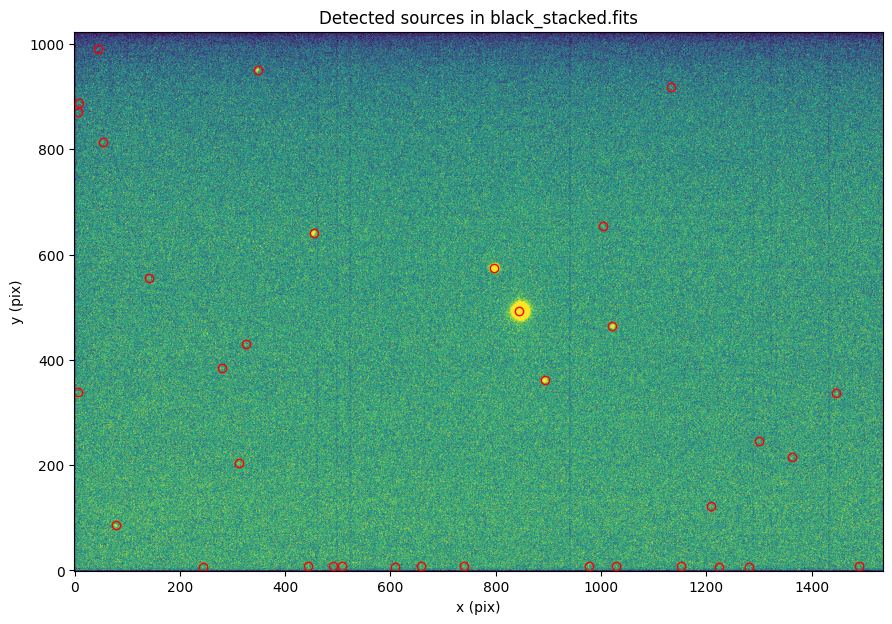

Processing blue_stacked.fits
     Found 15 stars in image


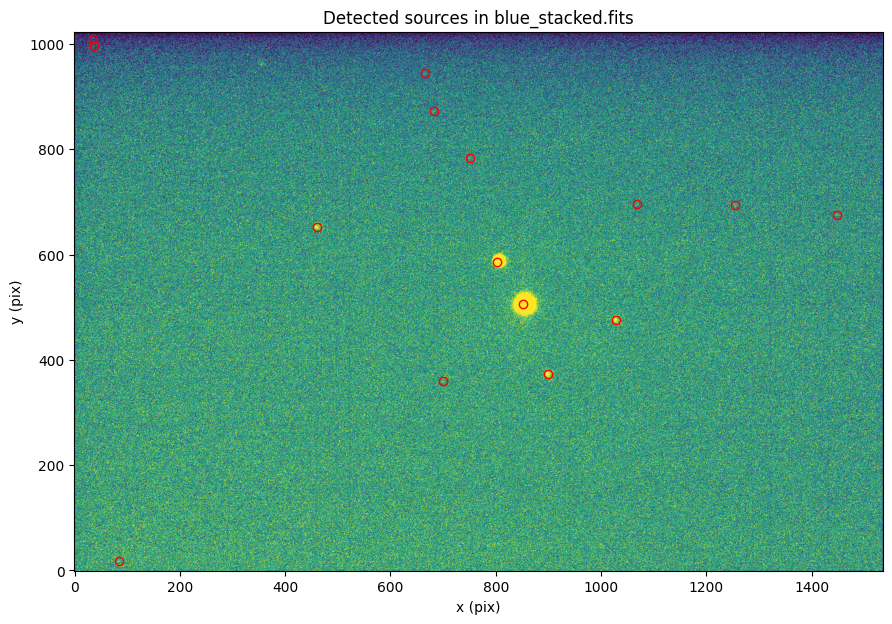

Processing green_stacked.fits
     Found 20 stars in image


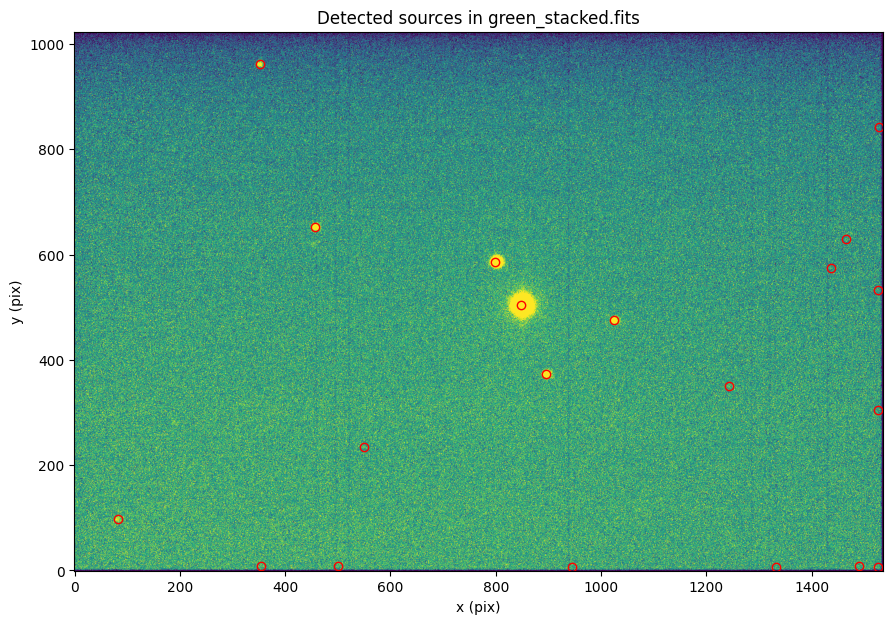

Processing red_stacked.fits
     Found 23 stars in image


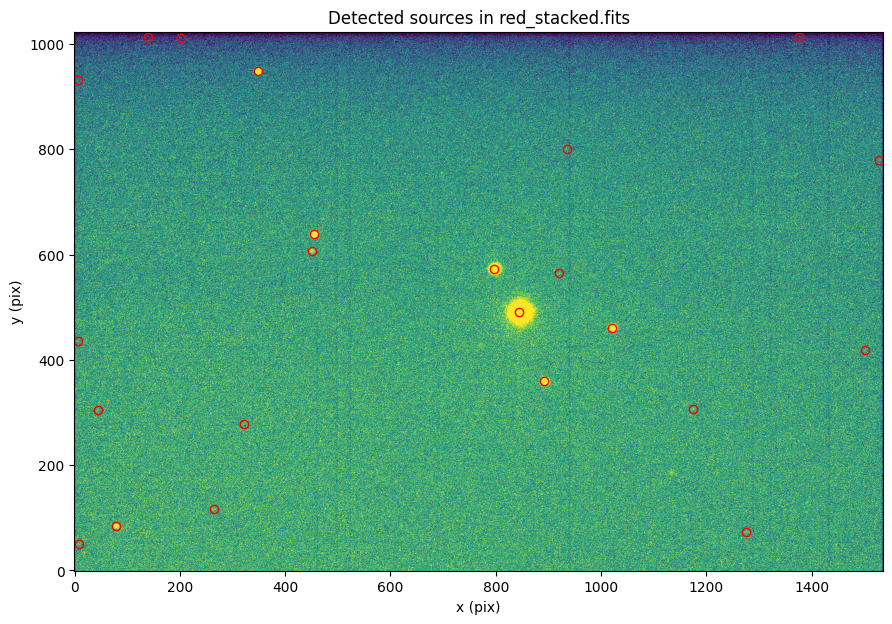

In [4]:
for file_path in file_list:
    # Load the image
    with fits.open(file_path) as hdul:
        image = hdul[0].data
    
    print(f"Processing {os.path.basename(file_path)}")
    
    ## Get background
    mean, median, std = sigma_clipped_stats(image, sigma=3.0, maxiters=20)
    
    ## Find stars
    daofind = DAOStarFinder(fwhm=10.0, threshold=4.0*std)
    sources = daofind(image - median)
    print(f"     Found {len(sources)} stars in image")
    
    # Plot the image with detected sources
    fig = plt.figure(figsize=(12,7))
    l1 = np.percentile(image[np.isfinite(image)].flatten(), 1)
    l2 = np.percentile(image[np.isfinite(image)].flatten(), 99)
    plt.imshow(image,clim=(l1,l2),origin='lower')
    plt.plot(sources["xcentroid"],sources["ycentroid"],'or',mfc='none')
    plt.xlabel("x (pix)")
    plt.ylabel("y (pix)")
    plt.title(f"Detected sources in {os.path.basename(file_path)}")
    plt.show()

In [5]:
nbright = 10
brightest = np.argsort(sources['flux'])[::-1][0:nbright]
brsources = sources[brightest]
print(brsources)

 id     xcentroid      ...         mag             daofind_mag     
--- ------------------ ... ------------------- --------------------
 12   844.897791863693 ... -15.314149934647148   -8.859305464621064
 14  796.4125018073028 ... -11.290890367635608   -4.890970528295263
  8  891.9783550076298 ...  -8.767971775244302  -2.2824285615273663
 16  454.1464456102317 ...  -8.576601743622872   -2.214719254481861
 11 1021.5763447591618 ...  -8.407759822769123  -1.8387792387449249
 20  348.6233249787621 ...  -8.030981635224839  -1.8101223787956822
  3  79.23942716934025 ...  -7.528645541085392  -1.3015566845390731
 15  451.2463774500304 ...  -6.809346495693976  -0.4941200390998262
  4 264.92543041924296 ...  -5.767558049707296 -0.03913997429268108
  7  1174.975128570259 ...  -5.755287753022193 -0.03211676666977394


In [6]:
x_init = np.array(brsources['xcentroid'])
y_init = np.array(brsources['ycentroid'])

Iterative PSF Photometry

In [7]:

# PSF is assumed to be a gaussian
psf_model = IntegratedGaussianPRF()

bkgstat = MMMBackground()

localbkg_estimator = LocalBackground(5, 10, bkgstat)


itPSF = IterativePSFPhotometry(psf_model,
                               fit_shape=(5,5),
                               localbkg_estimator=localbkg_estimator,
                               finder=daofind, aperture_radius = 4)

        Use `CircularGaussianSigmaPRF` or `CircularGaussianPRF` instead. [warnings]


In [8]:


init_params = QTable()
init_params['x'] =x_init
init_params['y'] =y_init
phot = itPSF(image, init_params=init_params)

In [9]:
phot

id,group_id,group_size,iter_detected,local_bkg,x_init,y_init,flux_init,x_fit,y_fit,flux_fit,x_err,y_err,flux_err,npixfit,qfit,cfit,reduced_chi2,flags
int32,int32,int32,int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,float64,float64,float64,int32
1,1,1,1,1752.600051641809,844.897791863693,490.9626378965954,662523.5793822471,844.810806081077,490.8913935237333,198779.66698127164,0.23620998183387798,0.23598327392442278,31766.762683115317,25,0.9215295166257933,-0.05756262377591105,nan,0
2,2,1,1,51.33806960031106,796.4125018073028,572.5236002741001,17371.134602538703,796.1612381239604,572.651815016386,5092.82246642971,0.24394337860928517,0.24403476295460774,840.1679871110086,25,0.9569025891476515,-0.05232967036063412,nan,0
3,3,1,1,21.209053695430143,891.9783550076298,359.597078651997,2358.3877531996895,891.8164547906923,359.7995710153996,441.3993138990991,0.24164333664098034,0.24143470651917248,72.15218354433942,25,0.9403657118157966,-0.06310717004135223,nan,0
4,4,1,1,19.388760134232022,454.1464456102317,638.8834213223494,2179.9229565208716,453.6226735795238,638.8481362024394,421.4401087436693,0.25494113162898246,0.2544772134300666,72.5783176336526,25,0.9784206201750755,-0.0535110477215456,nan,0
5,5,1,1,21.493418904885225,1021.5763447591618,461.5424105541372,1864.5848995888857,1021.7111052739383,461.7455421304729,301.21656793834916,0.22910794375140858,0.22879886578454106,46.64957278369383,25,0.9156382400894355,-0.05775510013533514,nan,0
6,6,1,1,16.609639369491816,348.6233249787621,948.6931691416645,1659.8879826691116,348.57604551634597,948.9393998789237,286.1334572151769,0.2396214467682368,0.2391297278652017,46.2896175309603,25,0.9363868698048486,-0.04504295029498379,nan,0
7,7,1,1,18.198972885498527,79.23942716934025,84.93491691373261,1305.8444993822548,78.57345286673396,84.78723789254296,161.98365974455405,0.24208121005082084,0.24129839643611484,26.443412848473237,25,0.8502138549984171,-0.07382259435793947,nan,0
8,8,1,1,16.53787623345829,451.2463774500304,607.3764106482665,1048.95206218561,450.4280751218631,606.9293135877115,80.05495140745226,0.3240933599717803,0.3217050575236457,17.431167907045936,25,1.090358205512286,-0.08965915295637569,nan,0
9,9,1,1,16.201810171782697,264.92543041924296,116.68643940263435,895.7736038331241,263.1871862287904,115.39432441642451,45.58604585825246,0.6501091821643309,0.6008141281308416,16.793367086246278,25,1.4321816509134724,0.09997775713205773,nan,0
